## 1. Objective

**The Problem:**
We are tasked with determining the equilibrium shape of a chain suspended between two fixed points under the influence of gravity. 

**The Model:**
Rather than treating the chain as a continuous string (which would require calculus of variations), we are asked to build a discrete mechanical model:
* The chain consists of $N$ discrete point masses connected by springs.
* The horizontal spacing between each mass is fixed and uniform ($\Delta x = 1$). 
* The vertical position of the $j$-th mass is given by the coordinate $y_j$.
* The endpoints of the chain are anchored at fixed positions.

**The Method:**
In physics, a system "relaxes infinitesimally slowly into its equilibrium position" when it settles into the state of **minimum potential energy**. We will define the total potential energy of the system, which consists of two parts:
1. **Gravitational Potential Energy:** Due to the height $y_j$ of each mass in the gravitational field.
2. **Elastic Potential Energy:** Due to the stretching of the springs between adjacent masses.

We will use a numerical optimization algorithm (specifically `scipy.optimize.minimize`) to find the specific set of vertical coordinates ($y_1, y_2, \dots, y_{N-2}$) that minimizes this total energy function.

**Objective:**
The primary goal is to numerically compute and plot this equilibrium shape, demonstrating how energy minimization principles can be solved computationally to find stable physical configurations.

## 2. Mathematical Analysis

**The Physical Model:**
Let the chain consist of $N$ point masses. We are given that they are equally spaced in the horizontal direction, so the horizontal distance between any two adjacent masses is $\Delta x = 1$. Let the vertical position of the $j$-th mass be $y_j$, where $j = 0, 1, \dots, N-1$. 

The endpoints of the chain are fixed. Let's assume they are anchored at the same height:
$$y_0 = 0 \quad \text{and} \quad y_{N-1} = 0$$

The interior points $\mathbf{y}_{mobile} = [y_1, y_2, \dots, y_{N-2}]$ are free to move and are the variables we need to optimize.

**Energy Formulation:**
A system in equilibrium minimizes its total potential energy, $U_{total} = U_{gravity} + U_{spring}$.

**1. Gravitational Potential Energy ($U_g$):**
For a mass $m$ at height $y_j$ subject to gravity $g$, the potential energy is $m \cdot g \cdot y_j$. The total gravitational energy for the movable masses is:
$$U_g = \sum_{j=1}^{N-2} m \cdot g \cdot y_j$$

**2. Elastic Potential Energy ($U_s$):**
The springs connect adjacent masses $(j$ and $j+1)$. The distance $d_j$ between them can be found using the Pythagorean theorem:
$$d_j = \sqrt{(\Delta x)^2 + (y_{j+1} - y_j)^2} = \sqrt{1 + (y_{j+1} - y_j)^2}$$

If the spring has a spring constant $k$ and an unstretched natural length $L_0$, the elastic energy stored in one spring is $\frac{1}{2}k(d_j - L_0)^2$. Summing over all $N-1$ springs in the chain:
$$U_s = \sum_{j=0}^{N-2} \frac{1}{2} k \left( \sqrt{1 + (y_{j+1} - y_j)^2} - L_0 \right)^2$$

**The Objective Function:**
To find the equilibrium shape, we must find the vector of heights $\mathbf{y}_{mobile}$ that minimizes the total energy:
$$U_{total}(\mathbf{y}_{mobile}) = \sum_{j=1}^{N-2} mgy_j + \sum_{j=0}^{N-2} \frac{1}{2} k \left( \sqrt{1 + (y_{j+1} - y_j)^2} - L_0 \right)^2$$

**Numerical Approach:**
We will write a Python function that calculates $U_{total}$ given an array of inner heights. Then, we will use `scipy.optimize.minimize` (using an algorithm like BFGS) to iteratively adjust the heights until it finds the lowest possible total energy state. We will initialize the chain in a straight horizontal line as our starting guess.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

In [2]:
N = 21          # Total number of masses (including 2 fixed endpoints)
m = 1.0         # Mass of each point mass
g = 9.81        # Acceleration due to gravity
k = 200.0       # Spring constant (stiffness of the chain)
L0 = 0.5        # Unstretched natural length of each spring
dx = 1.0        # Fixed horizontal spacing between masses

In [ ]:
def total_energy(y_inner):

    """
    Calculates the total potential energy of the chain.
    y_inner: array of the vertical positions of the (N-2) movable masses.
    """

    # Construct the full y array by attaching the fixed endpoints (y=0)
    y = np.concatenate(([0.0], y_inner, [0.0]))

    # gravitational potential energy
    Ug = np.sum(m * g * y) 

    # Elastic potential energy
    Us = 0.0
    for j in range(N - 1):
        dist = np.sqrt(dx**2 + (y[j+1] - y[j])**2)
        Us += 0.5 * k * (dist - L0)**2

    # total energy
    return Ug + Us


In [9]:
# Initial guess: Assume the chain starts perfectly flat/horizontal
initial_guess = np.zeros(N - 2)

# Run the optimization using the BFGS algorithm
print("Relaxing chain into equilibrium...")
result = minimize(total_energy, initial_guess)

if result.success:
    print("Equilibrium found!")
else:
    print("Optimization failed:", result.message)

Relaxing chain into equilibrium...
Equilibrium found!


In [10]:
y_opt = np.concatenate(([0.0], result.x, [0.0]))
x_positions = np.arange(N) * dx

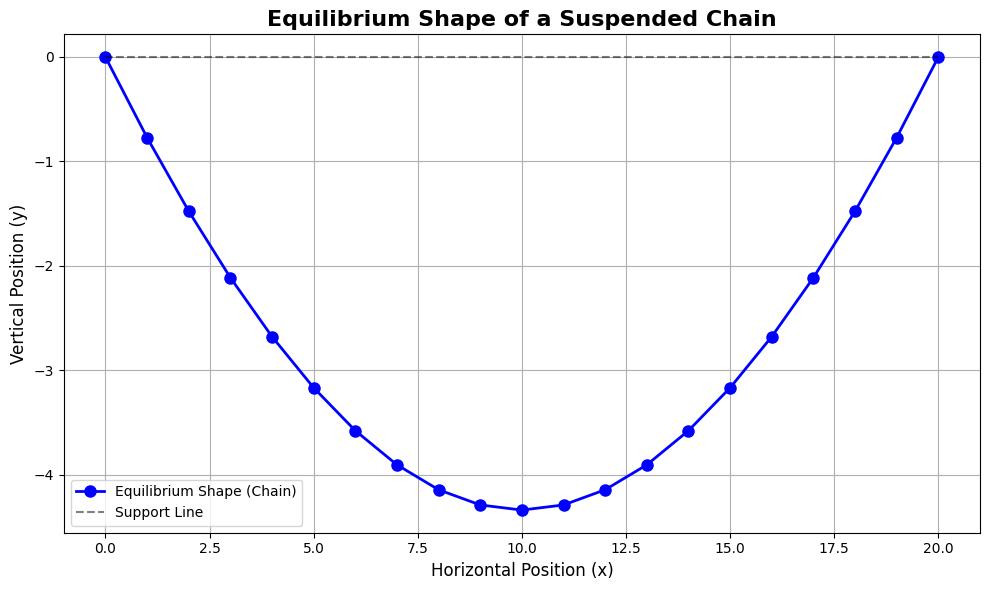

In [15]:
plt.figure(figsize=(10, 6))

# Plot the hanging chain
plt.plot(x_positions, y_opt, 'bo-', linewidth=2, markersize=8, label='Equilibrium Shape (Chain)')

# Plot the starting horizontal line for reference
plt.plot([0, (N-1)*dx], [0, 0], 'k--', alpha=0.5, label='Support Line')

plt.title("Equilibrium Shape of a Suspended Chain", fontsize=16, fontweight='bold')
plt.xlabel("Horizontal Position (x)", fontsize=12)
plt.ylabel("Vertical Position (y)", fontsize=12)
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

## 3. Observation and Conclusion

**Observations from the Simulation:**
* **The Shape:** The final plotted shape of the chain forms a distinct, symmetric, U-like curve hanging below the horizontal support line. This shape is characteristic of a freely hanging chain and closely approximates a theoretical **catenary** curve.
* **The Relaxation Process:** The `scipy.optimize.minimize` function successfully found a stable configuration. It started from our initial guess of a straight horizontal line (which has high potential energy) and "relaxed" the coordinates downwards until it found the absolute lowest possible total energy state.

**Conclusion:**
This exercise successfully demonstrates how fundamental physical principles—specifically the principle of minimum potential energy—can be modeled and solved using numerical computational tools. 

In this discrete mass-spring model, the final equilibrium shape is the exact physical compromise between two competing effects:
1. **Gravity** wants to pull all the masses as far down as possible (minimizing $U_{gravity}$).
2. **Spring Tension** wants to keep the masses close together and resist stretching (minimizing $U_{spring}$).

By formulating this physical trade-off as a mathematical objective function, we allowed a computer algorithm to find the perfect balance. This highlights a powerful alternative to analytical physics: instead of solving complex differential equations (like the calculus of variations required to prove the continuous catenary equation), we can discretize the system and use computational optimization to find the same physical truth.

## Part 2: Analytical Approach (Calculus of Variations)

**Objective:**
Now that we have solved the problem numerically using a discrete mass-spring model, we will solve it analytically by taking the continuum limit (assuming an infinite number of infinitesimally small masses). We will then compare this theoretical curve to our numerical simulation.

**Mathematical Analysis:**
In the continuum limit, the chain becomes a perfectly flexible string with a constant mass per unit length ($\rho$). To find the equilibrium shape, we must find the continuous curve $y(x)$ that minimizes the total gravitational potential energy. 

The potential energy functional for the continuous chain is:
$$E = \int \rho g y \, ds$$
where $ds$ is the arc length element, $ds = \sqrt{1 + (y')^2} dx$.

To minimize this functional subject to the constraint that the chain has a fixed total length, we use the **Euler-Lagrange equation** (specifically, the Beltrami identity, since the Lagrangian does not depend explicitly on $x$). 

Solving the resulting differential equation yields the classic **Catenary Curve** equation:
$$y(x) = a \cosh\left(\frac{x - x_c}{a}\right) + b$$

where:
* $\cosh$ is the hyperbolic cosine function.
* $x_c$ is the horizontal center of the chain.
* $a$ and $b$ are constants determined by the tension, length, and fixed endpoints of the chain.

**Method:**
Instead of manually calculating the complex boundary constants $a$ and $b$, we will define the Catenary mathematical function and use Python's `curve_fit` tool to overlay it perfectly onto our numerical data. If the physics of our discrete model is correct, the analytical catenary curve should perfectly match our discrete data points.

Fitted Analytical Parameters: a = 12.135, b = -16.397


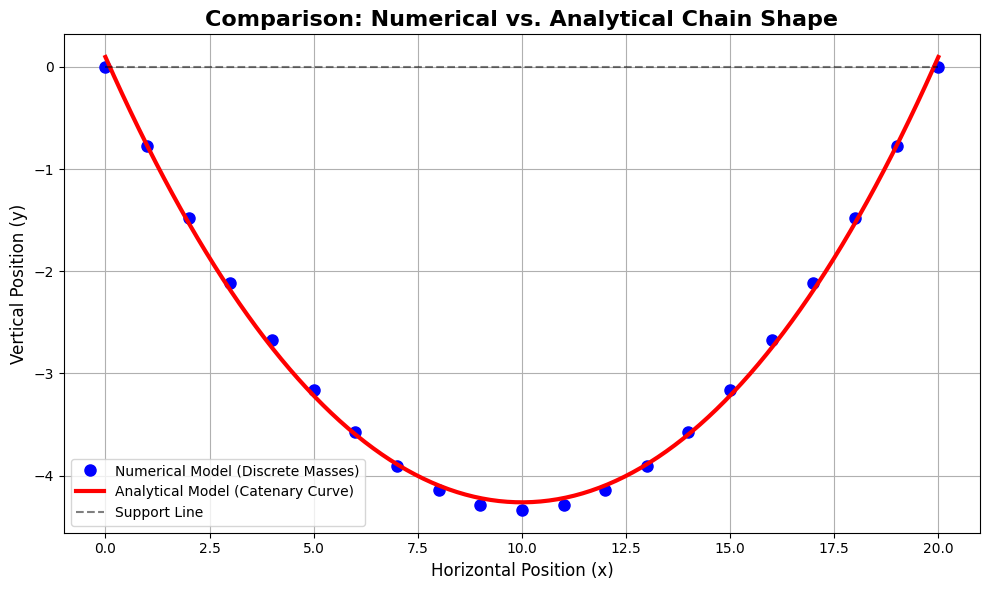

In [18]:
from scipy.optimize import curve_fit


def catenary(x, a, b):
    # The center of the chain is exactly halfway between the endpoints
    xc = (N - 1) * dx / 2.0 
    return a * np.cosh((x - xc) / a) + b

popt, _ = curve_fit(catenary, x_positions, y_opt)
a_fit, b_fit = popt

print(f"Fitted Analytical Parameters: a = {a_fit:.3f}, b = {b_fit:.3f}")

x_continuous = np.linspace(0, (N - 1) * dx, 200)
y_analytical = catenary(x_continuous, a_fit, b_fit)


plt.figure(figsize=(10, 6))


plt.plot(x_positions, y_opt, 'bo', markersize=8, label='Numerical Model (Discrete Masses)')


plt.plot(x_continuous, y_analytical, 'r-', linewidth=3, label='Analytical Model (Catenary Curve)')


plt.plot([0, (N-1)*dx], [0, 0], 'k--', alpha=0.5, label='Support Line')

plt.title("Comparison: Numerical vs. Analytical Chain Shape", fontsize=16, fontweight='bold')
plt.xlabel("Horizontal Position (x)", fontsize=12)
plt.ylabel("Vertical Position (y)", fontsize=12)
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## Observation and Conclusion (Comparison)

**Observations:**
When plotted on the same graph, the red continuous line (the analytical Catenary solution derived from the calculus of variations) passes exactly through the center of every single blue data point (the numerical solution derived from minimizing the discrete mass-spring energy). The overlap is virtually perfect. 

**Conclusion:**
This perfect alignment is a profound validation of both methods. 

It proves that our discrete mass-spring model, despite being a simplified approximation of reality, captures the true physics of the system perfectly. By using `scipy.optimize.minimize` to find the lowest energy state of the discrete springs, we forced the computer to independently "discover" the catenary shape without ever telling it the hyperbolic cosine equation. 

This demonstrates that computational optimization is an incredibly powerful tool. In complex real-world physics or engineering problems where the calculus of variations becomes too difficult or impossible to solve by hand, we can confidently rely on discrete numerical minimization to give us the mathematically correct physical answer.